In [1]:
import os
import sys
import gc
os.chdir('/zhome/71/c/146676/texture_tomography')
import h5py
import numpy as np
from pathlib import Path

from package.texture_tomography.operators.pfo_single_material import PFO_SINGLE, estimate_L_power
from package.texture_tomography.operators.pfo_and_projection_batched_opencl import PFO_OPENCL_BATCHED

import matplotlib.pyplot as plt
from multiprocessing import Pool
import yaml


from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_huber_opencl import FISTAHuberOpenCL
from package.texture_tomography.gpu_live_tracker import GPUMemoryLogger
from package.texture_tomography.operators.memory_tracker import MemoryCounter
import pyopencl.array as clarray
from package.texture_tomography.multiresolution_refiner import OrientationTree, invert_grid
from package.texture_tomography.material import Material
from scipy.spatial.transform import Rotation as R

from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
config_path = "configs/aluminum_config_single.yaml"

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

N_chi = cfg['N_chi']
N_rot = cfg['N_rot']
N_theta = cfg['N_theta']
Nx = cfg['Nx']
Ny = cfg['Ny']
datapath = cfg["datapath"]
filename_integrated = cfg["integrated_file"]
cif_path = cfg["cif_path"]
cor_offset = cfg["cor_offset"]
wavelength_kev = cfg['wavelength']
min_two_theta = cfg['min_two_theta']
max_two_theta = cfg['max_two_theta']
reflection_cutoff = cfg['reflection_cutoff']
filename = datapath + filename_integrated

In [3]:
with h5py.File(filename, "r") as f:
    dset = f["I"]
    arr = np.empty(dset.shape, dtype=dset.dtype)
    dset.read_direct(arr)

In [4]:
arr = arr/arr.sum(axis=(0,1,2), keepdims = True)*arr.sum()*10
all_data_reshaped1 = arr.reshape((3000, Nx, N_chi*N_theta))
all_data_reshaped = all_data_reshaped1[::3000//N_rot]/(3000//N_rot)

for i in range(1,3000//N_rot):
    all_data_reshaped += all_data_reshaped1[i::3000//N_rot]/(3000//N_rot)

In [5]:
cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
N_mat = len(filenames)


path = cif_folder / filenames[0]
material = Material.from_cif(
    cif_path=path,
    wavelength_kev=wavelength_kev,
    min_two_theta=min_two_theta,
    max_two_theta=max_two_theta,
    intensity_cutoff_fraction=reflection_cutoff,
)



grid_resolution_parameter = 34      # example
kernel_sigma = 0.058            # example
sigma_levels = [kernel_sigma]      # start with single level


grid = OrientationTree.from_hopf_fzone(
    material.point_group_matrices,
    grid_resolution_parameter=grid_resolution_parameter,
    sigma_levels=sigma_levels,
)

In [6]:
# A material contains a list of reflections with te following info.
#  Miller index class, multiplicity, d-spacing, scattering angle (2theta), and intensity.
#  A material also has one of 7 symmetry groups with te relevant parameters, and point group matrices
two_theta = (material.reflections['two_theta'])

In [7]:
print(N_rot, Nx, N_chi* N_theta)
print(all_data_reshaped.shape)

print(material.reflections)
print(len(grid.active_leaf_nodes()))


500 148 900
(500, 148, 900)
[([1, 1, 1],  8, 2.3380261 , 0.15253486, 100.        )
 ([2, 0, 0],  6, 2.02479   , 0.17618918,  50.38905341)
 ([2, 2, 0], 12, 1.43174274, 0.24949356,  37.43010365)
 ([3, 1, 1], 24, 1.22099431, 0.29284422,  45.15376884)
 ([3, 3, 1], 24, 0.92903737, 0.38588877,  15.53024153)]
6255


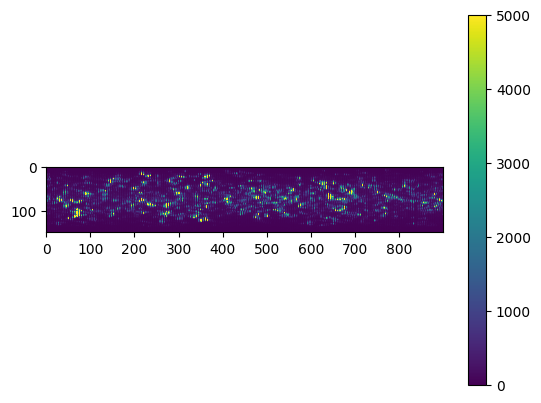

In [8]:
plt.imshow(all_data_reshaped[0])
plt.clim([0,5000])
plt.colorbar()

In [9]:
op = PFO_SINGLE(
        cfg = cfg,
        material=material,
        grid=grid,
        max_gb=1.0,
        verbose=True,
        normalized = True,)


queue = op.queue
Nx, Ny, K = op.Nx, op.Ny, op.K

x_gpu = clarray.zeros(
    queue,
    (Nx, Ny, K),
    dtype=np.float32,
    order="F",
)

out_cpu = np.ascontiguousarray(
    all_data_reshaped,
    dtype=np.float32
)
out_gpu = clarray.to_device(queue, out_cpu)
assert out_gpu.flags.c_contiguous
norm_sq = estimate_L_power(op, niter=7, seed=0, eps=1e-30, verbose=1)
solver = FISTAHuberOpenCL(op, prox_kind="nonneg", lam=1*1e-5, L=1.1*norm_sq, huber_delta=4000.0)

solver.run(x_gpu, out_gpu, niter=75, verbose=1, diagnostics_interval=1)
prediction = op.direct(x_gpu)
#prediction = op.adjoint(out_gpu)
coeffs = x_gpu.get().transpose((0,1,2))[::-1,::-1]
op.free_memory()
#del x_gpu
del out_gpu
gc.collect()


0.3562848439565492
[0.15253486 0.17618918 0.24949357 0.29284424 0.3858888 ]

=== OpenCL buffer allocation summary ===
coeffs_sino_F                 : shape=(148x500x596),   168.24 MB
coeffs_sino_C                 : shape=(500x148x596),   168.24 MB
_coeffs_batch_F               : shape=(148x148x596),    49.80 MB
_basis_batch_kmax             : shape=(500x596x180x5),  1023.10 MB
_basis_batch_transpose_kmax   : shape=(500x900x596),  1023.10 MB
_grid_inv_kmax                : shape=(596x9),     0.02 MB
_inv_sigma2_kmax              : shape=(596),     0.00 MB
_norm_factor_kmax             : shape=(596),     0.00 MB
---------------------------------------
TOTAL GPU buffer memory:  2432.52 MB

[power 01] L_est=7.035755e+06  ||z||=1.340869e+08
[power 02] L_est=6.566711e+10  ||z||=1.298233e+11
[power 03] L_est=3.304650e+11  ||z||=3.411043e+11
[power 04] L_est=3.594144e+11  ||z||=3.607409e+11
[power 05] L_est=3.630678e+11  ||z||=3.632579e+11
[power 06] L_est=3.635953e+11  ||z||=3.636241e+11
[pow

0

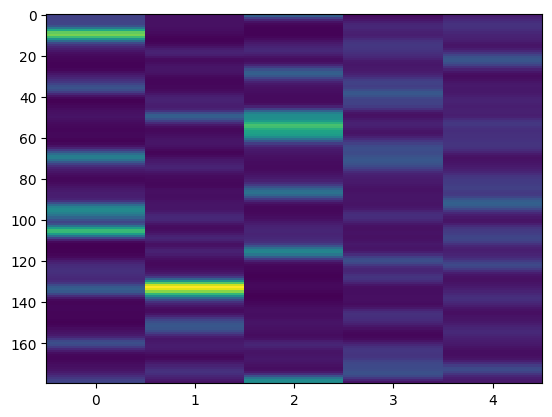

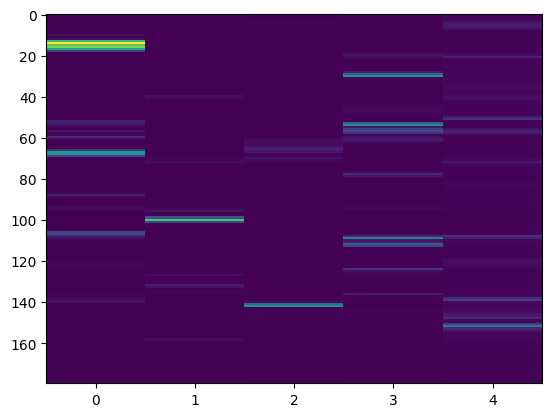

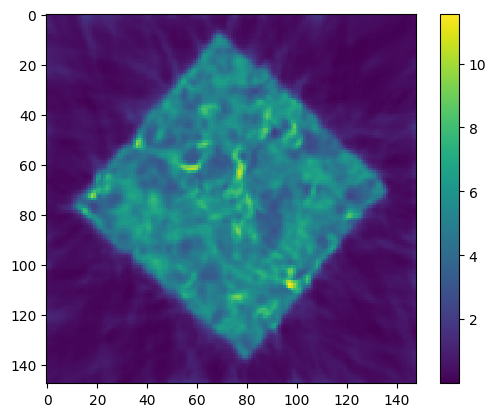

In [10]:
prediction_cpu = prediction.get().reshape((N_rot, Nx, N_chi, N_theta))
plt.imshow(prediction_cpu[0,90], aspect='auto', interpolation='nearest')
plt.show()
plt.imshow(arr[0,110], aspect='auto', interpolation='nearest')
plt.show()

plt.imshow(coeffs.sum(axis=-1), interpolation='nearest')
plt.colorbar()

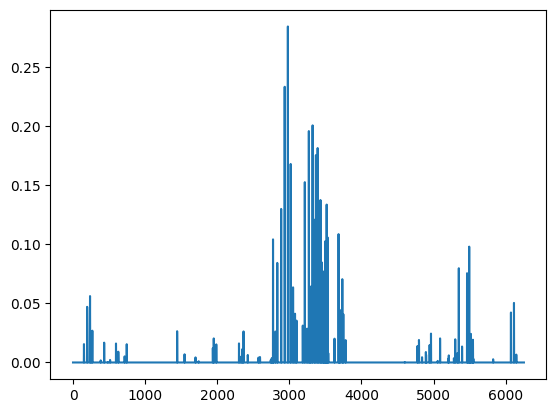

In [11]:
plt.plot(coeffs[70,60])

In [14]:
with h5py.File('/work3/msaca/textomo_run_009/reconstruction.h5', "r") as f:
    dset = f["x"]
    coeffs = np.empty(dset.shape, dtype=dset.dtype)
    dset.read_direct(coeffs)

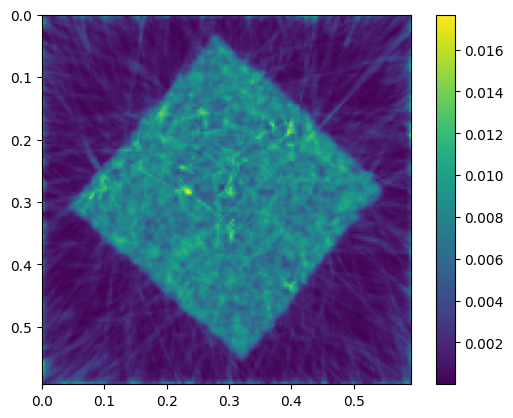

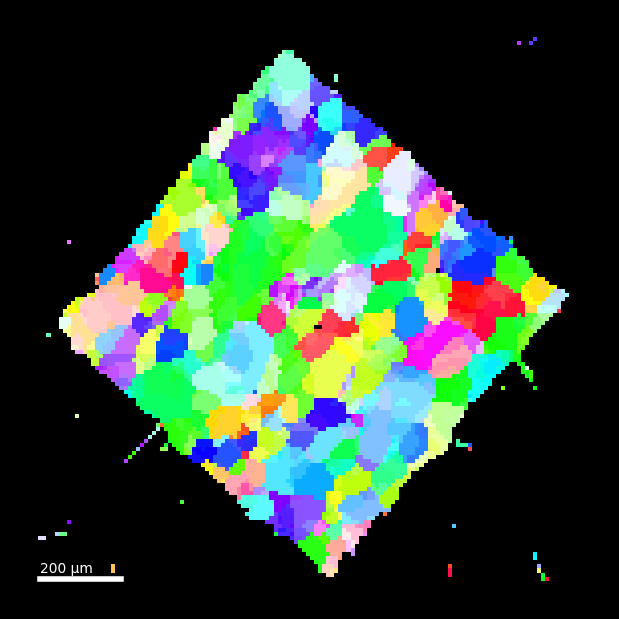

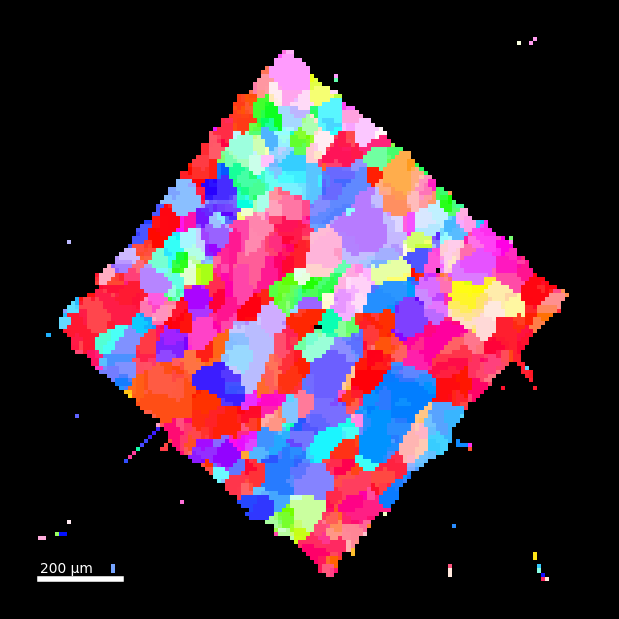

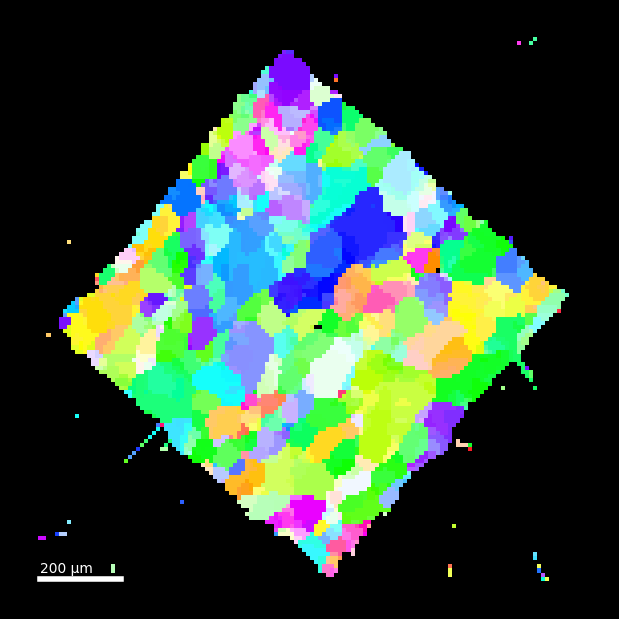

In [25]:
grid_sp = grid.rotations_at_level(0)
grid_sp = R.concatenate(grid_sp)

stepsize = 0.004
imshow_opts = {'extent':(0, coeffs.shape[0]*stepsize, coeffs.shape[1]*stepsize, 0)}

plt.imshow(coeffs.sum(axis=2), **imshow_opts)
plt.colorbar()
plt.show()

IVP_map_direction = [1,0,0]
ipfkey = plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(IVP_map_direction))
orientations = Orientation.from_scipy_rotation(grid_sp)

orientations.symmetry = ipfkey.symmetry
rgb_z = ipfkey.orientation2color(orientations)[np.argmax(coeffs, axis = -1)]
mask = coeffs.sum(axis=2)>0.0035
mask[:7] = False
mask[-7:] = False
mask[:,:7] = False
mask[:,-7:] = False
rgb_z[~mask] *= 0
fig, ax = plt.subplots(figsize=(6,6), facecolor='black')
ax.set_facecolor('black')

ax.imshow(rgb_z[::-1, ::-1],
          extent=(0, coeffs.shape[0]*stepsize,
                  coeffs.shape[1]*stepsize, 0))
ax.axis('off')

px_um, npx = 10, 20
L = npx*stepsize

x0 = 0.05*coeffs.shape[0]*stepsize
y0 = 0.95*coeffs.shape[1]*stepsize

ax.plot([x0, x0+L],[y0,y0],lw=4,color='w')
ax.text(x0, y0-0.03*coeffs.shape[1]*stepsize, f"{npx*px_um} µm",
        color='w', ha='left', va='top')

plt.tight_layout(pad=0)
plt.savefig('/work3/msaca/textomo_run_009/ipf_y.png', dpi=600)
plt.show()


IVP_map_direction = [0,1,0]
ipfkey = plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(IVP_map_direction))
orientations = Orientation.from_scipy_rotation(grid_sp)
orientations.symmetry = ipfkey.symmetry
rgb_z = ipfkey.orientation2color(orientations)[np.argmax(coeffs, axis = -1)]
rgb_z[~mask] *= 0
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6), facecolor='black')
ax.set_facecolor('black')

ax.imshow(rgb_z[::-1, ::-1],
          extent=(0, coeffs.shape[0]*stepsize,
                  coeffs.shape[1]*stepsize, 0))
ax.axis('off')

px_um, npx = 10, 20
L = npx*stepsize

x0 = 0.05*coeffs.shape[0]*stepsize
y0 = 0.95*coeffs.shape[1]*stepsize

ax.plot([x0, x0+L],[y0,y0],lw=4,color='w')
ax.text(x0, y0-0.03*coeffs.shape[1]*stepsize, f"{npx*px_um} µm",
        color='w', ha='left', va='top')

plt.tight_layout(pad=0)
plt.savefig('/work3/msaca/textomo_run_009/ipf_z.png', dpi=600)
plt.show()


IVP_map_direction = [0,0,1]
ipfkey = plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(IVP_map_direction))
orientations = Orientation.from_scipy_rotation(grid_sp)
orientations.symmetry = ipfkey.symmetry
rgb_z = ipfkey.orientation2color(orientations)[np.argmax(coeffs, axis = -1)]
rgb_z[~mask] *= 0
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6), facecolor='black')
ax.set_facecolor('black')

ax.imshow(rgb_z[::-1, ::-1],
          extent=(0, coeffs.shape[0]*stepsize,
                  coeffs.shape[1]*stepsize, 0))
ax.axis('off')

px_um, npx = 10, 20
L = npx*stepsize

x0 = 0.05*coeffs.shape[0]*stepsize
y0 = 0.95*coeffs.shape[1]*stepsize

ax.plot([x0, x0+L],[y0,y0],lw=4,color='w')
ax.text(x0, y0-0.03*coeffs.shape[1]*stepsize, f"{npx*px_um} µm",
        color='w', ha='left', va='top')

plt.tight_layout(pad=0)
plt.savefig('/work3/msaca/textomo_run_009/ipf_x.png', dpi=600)
plt.show()


In [16]:
import numpy as np
from orix.quaternion import Orientation
import orix.quaternion.symmetry as qs

Nx, Ny, K = coeffs.shape

# dominant orientation per pixel
k_star = np.argmax(coeffs, axis=-1)

# build orientation field
ori_flat = Orientation.from_scipy_rotation(grid[k_star.ravel()])
ori = ori_flat.reshape(Nx, Ny)

# set symmetry once
ori.symmetry = qs.Oh

kam = np.zeros((Nx, Ny), dtype=np.float32)
counts = np.zeros((Nx, Ny), dtype=np.int32)

# -------------------------------------------------
# 4-neighbour (cardinal directions)
# -------------------------------------------------

# right
ang = ori[:, :-1].angle_with(ori[:, 1:])
ang = np.rad2deg(ang)
kam[:, :-1] += ang
kam[:, 1: ] += ang
counts[:, :-1] += 1
counts[:, 1: ] += 1

# down
ang = ori[:-1, :].angle_with(ori[1:, :])
ang = np.rad2deg(ang)
kam[:-1, :] += ang
kam[1: , :] += ang
counts[:-1, :] += 1
counts[1: , :] += 1

# -------------------------------------------------
# Diagonals
# -------------------------------------------------

# down-right
ang = ori[:-1, :-1].angle_with(ori[1:, 1:])
ang = np.rad2deg(ang)
kam[:-1, :-1] += ang
kam[1: , 1: ] += ang
counts[:-1, :-1] += 1
counts[1: , 1: ] += 1

# down-left
ang = ori[:-1, 1:].angle_with(ori[1:, :-1])
ang = np.rad2deg(ang)
kam[:-1, 1: ] += ang
kam[1: , :-1] += ang
counts[:-1, 1: ] += 1
counts[1: , :-1] += 1

# -------------------------------------------------
# Final average
# -------------------------------------------------
kam /= np.maximum(counts, 1)
mask = coeffs.sum(axis=-1) > 0.03
kam_masked = np.zeros_like(kam)
kam_masked[mask] = kam[mask]
plt.imshow(kam_masked)
plt.colorbar()
plt.show()
print("KAM stats:")
print("min:", np.nanmin(kam))
print("max:", np.nanmax(kam))
print("mean:", np.nanmean(kam))

TypeError: 'OrientationTree' object is not subscriptable

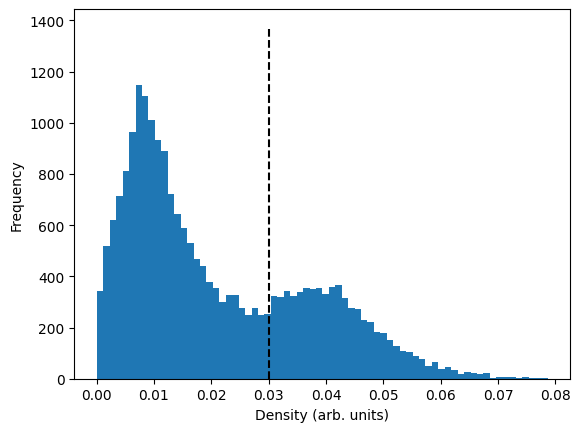

AttributeError: 'numpy.ndarray' object has no attribute 'apply'

In [23]:
odf = odfs.GaussianRBF(grid, point_groups.octahedral, kernel_sigma)
B = op.materials[0]._compute_reciprocal_lattice_matrix()

# Pick a threshold value to determine what pixels to plot.
mask_threshold = 0.03
dens = np.sum(coeffs, axis = -1)
mask_den = dens > mask_threshold
freq = plt.hist(dens.flatten(), bins = 70)[0]
# plt.ylim(0, np.max(freq[5:])*1.2)
plt.plot([mask_threshold]*2, [0, np.max(freq[5:])*1.2], 'k--')
plt.xlabel('Density (arb. units)')
plt.ylabel('Frequency')
plt.show()

# Pick a direction to compute the IPV map color
IVP_map_direction = np.array([0, 0, 1])
pole_figure_hkl = np.array([0, 0, 1])
example_voxel = (50, 50, 0)
stepsize = 0.003

voxel_coeffs = coeffs[example_voxel[0], example_voxel[1],:]
polefigure, theta_grid, phi_grid = odf.make_polefigure_map(voxel_coeffs,  B @ pole_figure_hkl)



imshow_opts = {'extent':(0, coeffs.shape[0]*stepsize, coeffs.shape[1]*stepsize, 0)}
pcolor_polar_opts = {'rasterized':True, 'edgecolors':'face', 'vmin':0}
mask_2d = np.sum(coeffs, axis = -1) > mask_threshold

max_orientation_index = np.argmax(coeffs, axis = -1)
max_orientation_index[~mask_2d] = -1
IVP_map_direction_normed = IVP_map_direction / np.linalg.norm(IVP_map_direction)
grid_ivp_directions = invert_grid(grid).apply(IVP_map_direction_normed)
max_orientation = grid_ivp_directions[max_orientation_index]
ivp_map_rgb = plot_tools.IPF_color(max_orientation, 'cubic')
ivp_map_rgb[~mask_2d] = 1 # (1 if you want white background, 0 if you want black background )

J = np.sqrt(np.var(coeffs, axis = -1)) / np.mean(coeffs, axis = -1)
J[~mask_den[:,:]] = 0

plt.style.use('dark_background')
fig, ax = plt.subplots(1, 1, figsize=(7,7))
im = ax.imshow(np.sum(coeffs, axis = -1), **imshow_opts)
plt.tight_layout()
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

plt.style.use('dark_background')
fig, ax = plt.subplots(1, 1, figsize=(7,7))
im = ax.imshow(ivp_map_rgb, **imshow_opts)
plt.tight_layout()
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

 # Build the plot
fig = plt.figure(figsize = (10, 6))

def tomogram_set_axes(ax):
    ax.set_xlabel('y (mm)')
    ax.set_ylabel('x (mm)')
    ax.grid()

# PLot IVP-map
ax = plt.subplot(2,2,2)
# mask_ivp = np.stack((mask, mask, mask), axis = 2).reshape(mask.shape[0],mask.shape[0],3)
# ax.imshow(ivp_map_rgb*mask_ivp, **imshow_opts)
ax.imshow(ivp_map_rgb, **imshow_opts)

ax.plot((example_voxel[1]+0.5)*stepsize, (example_voxel[0]+0.5)*stepsize, 'kx')
ax.text((example_voxel[1]+0.5)*stepsize - 0.2, (example_voxel[0]+0.5)*stepsize - 0.1, 'example voxel', color = 'k')
tomogram_set_axes(ax)
ax = fig.add_subplot([0.72, 0.55, 0.15, 0.15], polar = True)
plot_tools.make_color_legend(ax, 'cubic')

# Plot texture index
ax = plt.subplot(2,2,1)
img = ax.imshow(J, **imshow_opts, vmax = 8)
tomogram_set_axes(ax)
ax.set_title('Texture index')

# PLot pole figure
ax = plt.subplot(2,2,3, polar=True)        
img = ax.pcolormesh(phi_grid, np.arctan(theta_grid/2), polefigure, **pcolor_polar_opts)
ax.set_yticks([np.arctan(ii*np.pi/8) for ii in range(1,2)])
ax.set_yticklabels(['45°'])
ax.yaxis.label.set_color('w')
ax.set_title('Pole figure')
IVP_map_direction_normed = IVP_map_direction_normed * np.sign(IVP_map_direction_normed[2])
IVP_map_theta = np.arccos(IVP_map_direction_normed[2])
IVP_map_phi = np.arctan2(IVP_map_direction_normed[1], IVP_map_direction_normed[0])
ax.plot(IVP_map_phi, np.arctan(IVP_map_theta/2), 'wx')
ax.text(IVP_map_phi+0.3, np.arctan(IVP_map_theta/2), 'IVP direction',color = 'w')

# PLot ODF modes in Rodriguez
ax = plt.subplot(2,2,4, projection='3d')
voxel_coeffs = coeffs[example_voxel[0], example_voxel[1],:]
plot_tools.plot_orientation_coeffs(voxel_coeffs, grid, ax, point_group_string='cubic')
ax.view_init(elev = 60)
ax.set_title('ODF coefficients')

fig.tight_layout()
fig.show()

In [8]:

import numpy as np
from scipy.optimize import brent
import pyopencl.array as clarray


def scaled_l2_loss(out_gpu, pred_gpu):
    """
    Computes:
        0.5 * (||y||^2 - <y,p>^2 / <p,p>)
    """

    yp = clarray.vdot(out_gpu, pred_gpu)
    pp = clarray.vdot(pred_gpu, pred_gpu)
    yy = clarray.vdot(out_gpu, out_gpu)

    # pull scalars only
    yp = float(yp.get())
    pp = float(pp.get())
    yy = float(yy.get())

    return 0.5 * (yy - (yp * yp) / pp)


def optimize_peak_width(
    pw_init,
    x_sol_gpu,
    out_gpu,
    kernel_sigma,
    op,
    pw_bounds=(1e-4, 5e-2),
):
    """
    Optimizes peak_width with fixed kernel_sigma.
    """

    log_lo, log_hi = np.log(pw_bounds[0]), np.log(pw_bounds[1])

    def obj(log_pw):
        pw = np.exp(log_pw)
        pred = op.forward_kernel_width(
            x_sol_gpu,
            peak_width=pw,
            kernel_sigma=kernel_sigma
        )
        return scaled_l2_loss(out_gpu, pred)

    log_pw_opt = brent(
        obj,
        brack=(log_lo, np.log(pw_init), log_hi),
        tol=1e-3,
    )

    return np.exp(log_pw_opt)


def optimize_kernel_sigma(
    ks_init,
    x_sol_gpu,
    out_gpu,
    peak_width,
    op,
    ks_bounds=(1e-3, 1.0),
):
    """
    Optimizes kernel_sigma with fixed peak_width.
    """

    log_lo, log_hi = np.log(ks_bounds[0]), np.log(ks_bounds[1])

    def obj(log_ks):
        ks = np.exp(log_ks)
        pred = op.forward_kernel_width(
            x_sol_gpu,
            peak_width=peak_width,
            kernel_sigma=ks,
            coefficient_constant=1.0,
        )
        return scaled_l2_loss(out_gpu, pred)

    log_ks_opt = brent(
        obj,
        brack=(log_lo, np.log(ks_init), log_hi),
        tol=1e-3,
    )

    return np.exp(log_ks_opt)




In [9]:
pw = op.peak_width        # initial guess
ks = op.kernel_sigma         # initial guess

print(f"Initial peak_width={pw:.4e}, kernel_sigma={ks:.4e}")

# for _ in range(1):
#     pw = optimize_peak_width(
#         pw,
#         x_sol_gpu=x_sol_gpu,
#         out_gpu=out_gpu,
#         kernel_sigma=ks,
#         op=op,
#     )

#     ks = optimize_kernel_sigma(
#         ks,
#         x_sol_gpu=x_sol_gpu,
#         out_gpu=out_gpu,
#         peak_width=pw,
#         op=op,
#     )

#     print(f"updated peak_width={pw:.4e}, kernel_sigma={ks:.4e}")


Initial peak_width=3.0000e-03, kernel_sigma=1.0000e-01


In [10]:
# op = PFO_OPENCL_BATCHED(
#         cfg = cfg,
#         two_thetas = two_theta,
#         verbose=False)

op.set_kernel_sigma(kernel_sigma=0.075)
op.set_peak_width(peak_width=pw)

queue = op.queue
Nx, Ny, K = op.Nx, op.Nx, op.K_sum

# x0_gpu = clarray.zeros(
#     queue,
#     (Nx, Ny, K),
#     dtype=np.float32,
#     order="F",
# )

out_cpu = np.ascontiguousarray(
    all_data_reshaped,
    dtype=np.float32
)
out_gpu = clarray.to_device(queue, out_cpu)
assert out_gpu.flags.c_contiguous
op.set_pf_batch_max_gb(4.0)
# l1 constant: 1e7
# tv constant: 1e-5
# L constant for l1: 5e11
solver = FISTAHuberOpenCL(op, prox_kind="nonneg_l1", lam=1e+7, L=1e12, huber_delta = 4000)


x_sol_gpu = solver.run(x_sol_gpu, out_gpu, niter=20, verbose=1, diagnostics_interval=1)
coeffs = x_sol_gpu.get().transpose((0,1,2))[::-1,::-1]

IndexError: list index out of range

In [16]:
prediction_gpu = op.direct(x_sol_gpu)
prediction_cpu = prediction_gpu.get().reshape((N_rot,Nx, N_chi, N_theta))

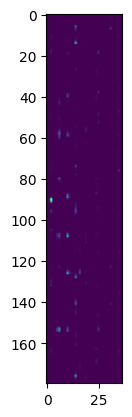

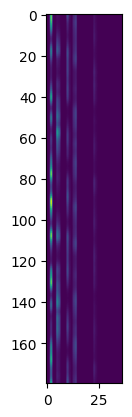

In [17]:
plt.imshow(all_data[150,80,:,:])
plt.show()

plt.imshow(prediction_cpu[150,80,:,:])
plt.show()

In [18]:
import numpy as np
from scipy.spatial.transform import Rotation as R

def mean_min_rotation_distance(grid: R) -> float:
    """
    Compute the mean nearest-neighbor distance on SO(3).

    Parameters
    ----------
    grid : scipy.spatial.transform.Rotation
        Rotation object with N rotations (len(grid) = N)

    Returns
    -------
    float
        Mean of the minimum geodesic distance (radians) between each
        rotation and its nearest distinct neighbor.
    """
    N = len(grid)
    if N < 2:
        raise ValueError("Grid must contain at least 2 rotations")

    min_dists = np.empty(N, dtype=np.float64)

    for i in range(N):
        # Relative rotations: R_i^{-1} * R_j
        rel = grid[i].inv() * grid

        # Geodesic distances (rotation angles)
        angles = rel.magnitude()

        # Exclude self-distance (exactly zero)
        angles[i] = np.inf

        min_dists[i] = angles.min()

    return float(min_dists.mean())


In [19]:
mean_dist = mean_min_rotation_distance(op.grid_list[0])
print(mean_dist)

AttributeError: 'PFO_OPENCL_BATCHED' object has no attribute 'grid_list'

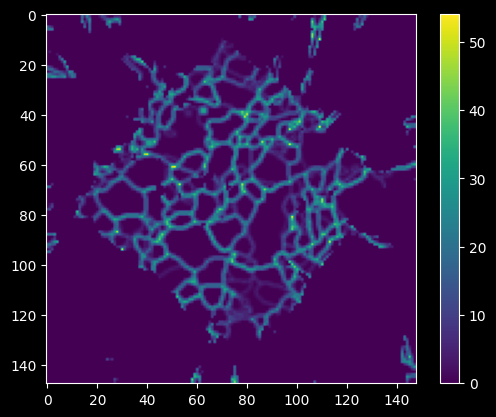

KAM stats:
min: 0.0
max: 56.477203
mean: 10.290805


In [ ]:
import numpy as np
from orix.quaternion import Orientation
import orix.quaternion.symmetry as qs

Nx, Ny, K = coeffs.shape

# dominant orientation per pixel
k_star = np.argmax(coeffs, axis=-1)

# build orientation field
ori_flat = Orientation.from_scipy_rotation(grid[k_star.ravel()])
ori = ori_flat.reshape(Nx, Ny)

# set symmetry once
ori.symmetry = qs.Oh

kam = np.zeros((Nx, Ny), dtype=np.float32)
counts = np.zeros((Nx, Ny), dtype=np.int32)

# -------------------------------------------------
# 4-neighbour (cardinal directions)
# -------------------------------------------------

# right
ang = ori[:, :-1].angle_with(ori[:, 1:])
ang = np.rad2deg(ang)
kam[:, :-1] += ang
kam[:, 1: ] += ang
counts[:, :-1] += 1
counts[:, 1: ] += 1

# down
ang = ori[:-1, :].angle_with(ori[1:, :])
ang = np.rad2deg(ang)
kam[:-1, :] += ang
kam[1: , :] += ang
counts[:-1, :] += 1
counts[1: , :] += 1

# -------------------------------------------------
# Diagonals
# -------------------------------------------------

# down-right
ang = ori[:-1, :-1].angle_with(ori[1:, 1:])
ang = np.rad2deg(ang)
kam[:-1, :-1] += ang
kam[1: , 1: ] += ang
counts[:-1, :-1] += 1
counts[1: , 1: ] += 1

# down-left
ang = ori[:-1, 1:].angle_with(ori[1:, :-1])
ang = np.rad2deg(ang)
kam[:-1, 1: ] += ang
kam[1: , :-1] += ang
counts[:-1, 1: ] += 1
counts[1: , :-1] += 1

# -------------------------------------------------
# Final average
# -------------------------------------------------
kam /= np.maximum(counts, 1)
mask = coeffs.sum(axis=-1) > 0.03
kam_masked = np.zeros_like(kam)
kam_masked[mask] = kam[mask]
plt.imshow(kam_masked)
plt.colorbar()
plt.show()
print("KAM stats:")
print("min:", np.nanmin(kam))
print("max:", np.nanmax(kam))
print("mean:", np.nanmean(kam))

In [ ]:
import numpy as np
from orix.quaternion import Orientation
import orix.quaternion.symmetry as qs

Nx, Ny, K = coeffs.shape
M = 5   # top-M ODF components (5–10 is typical)

# -------------------------------------------------
# Prepare orientation grid
# -------------------------------------------------
ori_grid = Orientation.from_scipy_rotation(grid)
ori_grid.symmetry = qs.Oh

# -------------------------------------------------
# Top-M ODF indices + weights
# -------------------------------------------------
idx = np.argpartition(coeffs, -M, axis=-1)[..., -M:]
wts = np.take_along_axis(coeffs, idx, axis=-1)

# normalize ODF per pixel
wts /= np.sum(wts, axis=-1, keepdims=True) + 1e-12

kam = np.zeros((Nx, Ny), dtype=np.float32)
counts = np.zeros((Nx, Ny), dtype=np.float32)

# -------------------------------------------------
# Helper: ODF-averaged misorientation
# -------------------------------------------------
def odf_misorientation(idx1, w1, idx2, w2):
    o1 = ori_grid[idx1.ravel()]
    o2 = ori_grid[idx2.ravel()]

    ang = o1.angle_with(o2)           # radians
    ang = np.rad2deg(ang)

    wprod = (w1[..., None] * w2[:, None]).reshape(-1)
    return np.sum(wprod * ang) / (np.sum(wprod) + 1e-12)

# -------------------------------------------------
# Neighbour offsets (8-neighbour)
# -------------------------------------------------
nbrs = [
    (0, 1), (1, 0), (0, -1), (-1, 0),
    (1, 1), (1, -1), (-1, 1), (-1, -1)
]

for dx, dy in nbrs:
    xs = slice(max(0, -dx), min(Nx, Nx - dx))
    ys = slice(max(0, -dy), min(Ny, Ny - dy))

    xs2 = slice(xs.start + dx, xs.stop + dx)
    ys2 = slice(ys.start + dy, ys.stop + dy)

    for i in range(xs.stop - xs.start):
        for j in range(ys.stop - ys.start):
            x, y = xs.start + i, ys.start + j
            x2, y2 = xs2.start + i, ys2.start + j

            ang = odf_misorientation(
                idx[x, y], wts[x, y],
                idx[x2, y2], wts[x2, y2],
            )

            kam[x, y] += ang
            counts[x, y] += 1

# -------------------------------------------------
# Final KAM
# -------------------------------------------------
kam /= np.maximum(counts, 1)

KeyboardInterrupt: 

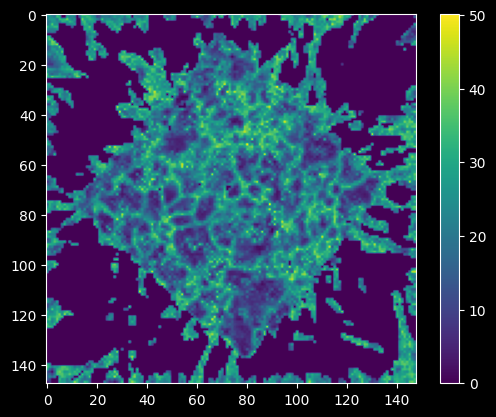

KAM stats:
min: 0.0
max: 50.204185
mean: 23.224014


In [ ]:
mask = coeffs.sum(axis=-1) > 0.03
kam_masked = np.zeros_like(kam)
kam_masked[mask] = kam[mask]
plt.imshow(kam_masked)
plt.colorbar()
plt.show()
print("KAM stats:")
print("min:", np.nanmin(kam))
print("max:", np.nanmax(kam))
print("mean:", np.nanmean(kam))